# Examples

This is a first example of an application of the differentiable programming paradigm in the context of mapping the brain’s functional connectivity. This toy example recapitulates the third experiment from our first preprint on this subject (“Covariance modelling”). The goal of this experiment is to create a simple, differentiable map of the dynamics of community structure in the brain’s functional connectome.

The connectome is a graph of the brain’s functional connectivity, where each node represents a brain region and each edge represents the strength of the connection between two regions. The community structure of the connectome is a partition of the nodes into groups that are more strongly connected to each other than to nodes in other groups. The *dynamics* of community structure is the evolution of the community structure over time. Here, we use a simple operationalisation of the dynamics that tracks only the extent to which a community is "present" or "absent" at each time point.

This tutorial steps through the code for this experiment.

#### Note

This notebook uses an old version of the `hypercoil` differentiable programming system that is written using `torch`. (We will at some point release a similar notebook using the new, `jax`-based implementation.) Because of this, it can be rather particular about library versions. To use this notebook, you can set up a new `conda` environment and install libraries as follows:

```bash
conda create -n ENV_NAME python=3.10
conda activate ENV_NAME
python3 -m pip install git+https://github.com/hypercoil/hypercoil.git@58f6ddc5402c361ef7d0750a70fc458667c842eb
python3 -m pip install hyve --ignore-requires-python
python3 -m pip install hyve-examples --ignore-requires-python
conda install ipython
python3 -m pip install jupyter notebook
```

## Loading the dataset

In this tutorial, we’ll perform the experiment using a subset of the Midnight Scan Club (MSC) dataset. We select a subset of the dataset to expedite the processing steps, and because we can find a rich community structure even using only this subset. The MSC dataset is a collection of fMRI scans of 10 subjects, each performing a number of in-scanner tasks across 10 scanning sessions. Here, we use the first 3 resting-state scans from each subject.

The MSC dataset is available from the OpenNeuro website. Below, we’re using a utility function to retrieve a version of the dataset that has already been preprocessed. The preprocessing includes, among other standard steps, dimensionality reduction using a 400-region parcellation (brain atlas) and denoising using a 36-parameter model of motion estimates and nuisance signals (including the mean global signal).

In [1]:
import pathlib
import torch
import pandas as pd

from hypercoil.data.functional import extend_to_max_size
from hypercoil.neuro.datasets import minimal_msc_download

torch.manual_seed(0)

dataset_root = f"{minimal_msc_download()}/data/MSC/ts/"
paths = pathlib.Path(dataset_root).glob("*ses-func0[1-3]*task-rest*ts.1D")
time_series = tuple(pd.read_csv(path, sep=" ", header=None) for path in paths)
time_series = tuple(
    torch.tensor(t.values.T, dtype=torch.float) for t in time_series
)
time_series = torch.stack(extend_to_max_size(time_series, 0.0))
assert time_series.shape == (30, 400, 814)

## Defining the model

Next, let’s define the model that will be learning the community structure. We need to define the model’s parameters, the model’s forward pass, and the model’s loss function. We begin here with the parameters. The model has two parameter tensors: one for the community structure and one for the dynamics of community structure. The community structure is a matrix of shape (n_nodes, n_communities), where each row represents a node and each column represents a community. The dynamics of community structure is a binary matrix of shape (n_time_points, n_communities), where each row represents a time point and each column represents a community.

We want to learn a community structure that is common to all subjects and all scans in the dataset. However, we also want the dynamics to be specific to each scan. To achieve this, we define the community structure as a parameter tensor that is shared across all scans, and we define the dynamics as a parameter tensor that is specific to each scan. We can achieve this by defining the community structure as a parameter tensor of shape (n_nodes, n_communities), and the dynamics as a parameter tensor of shape (n_scans, n_time_points, n_communities). The first dimension of the dynamics tensor will be used to index the dynamics of each scan.

We also want to impose some constraints on the values that the parameter tensors can take. For the community structure tensor, we’s ideally want each node to belong to exactly one community. But this would give us a combinatorial optimisation problem instead of a differentiable one, so we’ll relax this constraint to instead allow each node’s community assignment to be a categorical probability distribution over communities. We can achieve this by projecting the community structure tensor onto the probability simplex, which is the set of vectors whose elements are nonnegative and sum to 1.0. Behind the scenes, `hypercoil`’s `MultiLogit` (now `ProbabilitySimplexParameter`) implements this constraint using a softmax mapping.

For the dynamics tensor, we’d ideally want to impose the constraint that each community is either present or absent at each time point – but again, we’ll relax this constraint for the sake of differentiability. We’ll instead allow the presence of each community at each time point to vary continuously in (0, 1) using a `Logit` (now `MappedLogits`) parameter. Later, we’ll introduce some regularisations that encourage the dynamics to be close to binary.

(**Note**: In the updated version of `hypercoil`, there is no need to make `domain` a parameter of the model, or to handle its implementation using `property` decorators as below. Instead, imposing constraints works more like the `parametrization` system from `torch`:)

```python
def parameterise_model(model):
    model = ProbabilitySimplexParameter.map(
        model, where="affiliation", axis=-1)
    model = MappedLogits.map(
        model, where="dynamics")
    return model
```

The last model parameter is a scalar that sets the resolution of the community detection algorithm. This scalar, gamma, promotes discovery of more, smaller communities as it is increased. We won’t learn this parameter, but we’ll set it to a reasonable value for the purposes of this tutorial. In practice, we’ve found that a “default” value of 1 for gamma results in an unbalanced community structure that is dominated by a few large communities. We’ve found that a value of 5 for gamma results in a more balanced community structure.

With that said, let’s implement the model:

In [2]:
from torch.nn import Module, Parameter
from hypercoil.init.domain import (
    Logit,
    MultiLogit,
)


class DynamicCommunityModel(Module):
    n_nodes: int
    n_communities: int
    n_scans: int
    n_time_points: int
    gamma: float
    _affiliation: torch.Tensor
    _dynamics: torch.Tensor

    def __init__(
        self,
        n_nodes: int,
        n_scans: int,
        n_communities: int,
        n_time_points: int,
        gamma: float = 1.0,
        init_scale_affiliation: float = 0.05,
        init_scale_dynamics: float = 0.05,
        affiliation_domain: callable = MultiLogit(),
        dynamics_domain: callable = Logit(),
    ):
        super().__init__()
        self.n_nodes = n_nodes
        self.n_communities = n_communities
        self.n_scans = n_scans
        self.n_time_points = n_time_points
        self.gamma = gamma
        self.affiliation_domain = affiliation_domain
        self.dynamics_domain = dynamics_domain

        affiliation = torch.normal(
            mean=1.0,
            std=init_scale_affiliation,
            size=(n_nodes, n_communities)
        )
        dynamics = torch.normal(
            mean=0.5,
            std=init_scale_dynamics,
            size=(n_scans, n_communities, n_time_points)
        )
        self._affiliation = Parameter(affiliation)
        self._dynamics = Parameter(dynamics)
        self._affiliation.requires_grad = self._dynamics.requires_grad = True

    @property
    def affiliation(self):
        return self.affiliation_domain.image(self._affiliation)

    @property
    def dynamics(self):
        return self.dynamics_domain.image(self._dynamics)
    
    def forward(self, time_series: torch.Tensor) -> torch.Tensor:
        result = model_forward(
            time_series,
            self.affiliation,
            self.dynamics,
            self.gamma,
        )
        return result

## Defining the loss function

#### Modularity

Next, we should come up with an objective function that we can use to discover community structure in the brain. As a simple starting point, we can use the Girvan-Newman heuristic for modularity (`ModularityLoss`):

$\mathcal{L}_Q = \mathbf{1}^\intercal (\mathbf{H} \circ \mathbf{B}) \mathbf{1}$

where $\circ$ denotes the Hadamard product and $\mathbf{H} = \mathbf{C C}^\intercal$ is the community coaffiliation matrix for community affiliation $\mathbf{C}$. The *modularity matrix* $\mathbf{B} = \mathbf{A} - \gamma \mathbf{P}$ expresses the extent to which edges in the observed graph $\mathbf{A}$ deviate from expectation under the null model $\mathbf{P}$, subject to a resolution hyperparameter $\gamma$. The Girvan-Newman null model defines $\mathbf{P}_{GN} = \frac{\mathbf{A11}^\intercal \mathbf{A}}{\mathbf{1}^\intercal \mathbf{A} \mathbf{1}}$, which can be interpreted as the expected weight of connections between each pair of vertices if all existing edges are cut and then randomly rewired.

The modularity objective is applied to the time-averaged (or *static*) connectome and combined with *time-selective* (or *dynamic*) modularity objectives applied separately for each community. Specifically, let $\mathcal{C}_i$ be the $i$th community, and let $\mathbf{C}_i$ be the corresponding column of the assignment matrix $\mathbf{C}$.

Now, let $\mathbf{A}_{\mathcal{C}_i}$ be the covariance parameterised by a learnable time course (the *dynamics* parameter of our model above) $\mathbf{\Theta}_{\mathcal{C}_i}$ that our loss function will train to learn *changes in how modularised the community is over time*. Let $\mathbf{B}_{\mathcal{C}_i}$ be the corresponding modularity matrix and $\mathbf{H}_{\mathcal{C}_i} = \mathbf{C}_i \mathbf{C}_i^\intercal$ the coaffiliation for that single community.

The overall modularity loss will thus comprise a *static* term $\nu_{\mathrm{s}} \mathcal{L}_Q$ and a *dynamic* term $\nu_{\mathrm{d}} \sum_{i} \mathcal{L}_{Q,\mathcal{C}_i}$:

$\mathcal{L} = \nu_{\mathrm{s}} \mathcal{L}_Q +  \nu_{\mathrm{d}} \sum_{i} \mathcal{L}_{Q,\mathcal{C}_i} \\
    = \mathbf{1}^\intercal \left( \nu_{\mathrm{s}} \ \mathbf{H} \circ \mathbf{B} + \nu_{\mathrm{d}} \sum_{i} \mathbf{H}_{\mathcal{C}_i} \circ \mathbf{B}_{\mathcal{C}_i} \right) \mathbf{1}$

with static and dynamic multiplier hyperparameters $\nu_{\mathrm{s}}$ and $\nu_{\mathrm{d}}$ respectively.

#### Regularisation

We can place additional soft constraints on the modularisation dynamics by introducing penalisation factors to the loss function. (Not all of these were used in the paper---see the methods for details.)

* First, we can encourage each module to either be "on" or "off", with only brief transitions between these states, using a penalty that is minimised when the `dynamics` parameter is valued either 0 or 1 (`SymmetricBimodal`).
* Second, we can encourage smooth transitions between the "on" and "off" states by penalising the norm of the backwards difference in the `dynamics` parameter. This will generally prevent switching unless multiple consecutive frames are 
* Third, we can use a prior on the fraction of time that each community should cohere (i.e., be in an "on" state) (`ReducingLoss`: `"Cohesion"`).

#### Loss multipliers and containers

Loss modules generally accept a `nu` multiplier that determines how much that loss will be weighted in the overall combined objective function. Note that a `nu` of 1 for loss term $f$ might not be weighted more than a `nu` of (for example) 0.01 for loss term $g$ if $g$ tends to assume larger values given the data "seen" by the model during training.

A number of containers (`LossScheme`, `LossApply`) provide additional functionality, enabling decomposition of the loss function for diagnostics during training.

In [3]:
from hypercoil.engine import UnpackingModelArgument
from hypercoil.loss import (
    LossScheme,
    LossApply,
    LossArgument,
    ReducingLoss,
    ModularityLoss,
    SmoothnessPenalty,
    SymmetricBimodal,
)


def dynamic_community_loss(
    modularity_nu: float,
    smoothness_nu: float,
    dynamic_community_nu: float,
    bimodal_symmetric_nu: float,
    cohesion_nu: float,
    cohesion_fraction: float,
    gamma: float,
) -> LossScheme:
    loss = LossScheme([
        LossApply(
            ModularityLoss(nu=modularity_nu, name='Modularity', gamma=gamma),
            apply=lambda arg: UnpackingModelArgument(
                A=arg.corr_unparam,
                C=arg.affiliation,
            )
        ),
        LossApply(
            ReducingLoss(
                nu=dynamic_community_nu,
                name='DynamicCommunities',
                loss=lambda x: x.sum((-1, -2)),
                reduction=torch.mean,
            ),
            apply=lambda arg: -(arg.coaffiliation * arg.modularity)
        ),
        LossScheme([
            SmoothnessPenalty(nu=smoothness_nu),
            SymmetricBimodal(nu=bimodal_symmetric_nu, modes=(0, 1)),
            ReducingLoss(
                nu=cohesion_nu,
                name='Cohesion',
                loss=lambda x: (x.mean(-1) - cohesion_fraction) ** 2,
                reduction=torch.mean,
            ),
        ], apply=lambda arg: arg.dynamics),
    ])
    return loss

## Defining the forward pass

When we defined our model above, we passed the input and parameters to a `model_forward` function that we haven't yet implemented. Below, we define this function, which computes the functional connectivity matrix (as the correlation), the modularity matrix of the functional connectivity, and the coaffiliation matrix of the community affiliation parameter. These intermediates are all collated into a container that we will pass to our loss function in our training loop.

In [4]:
from hypercoil.functional import corr, expand_outer, modularity_matrix


def model_forward(
    time_series: torch.Tensor,
    affiliation: torch.Tensor,
    dynamics: torch.Tensor,
    gamma: float,
) -> torch.Tensor:
    # Compute the correlation matrix for each scan.
    corr_unparam = corr(time_series)
    corr_param = torch.relu(corr(time_series.unsqueeze(1), weight=dynamics))

    # Compute the modularity matrix for each scan.
    B = modularity_matrix(
        corr_param,
        gamma=gamma,
    )
    # Compute the community co-affiliation matrix.
    H = expand_outer(affiliation.T.unsqueeze(-1))

    # Build arguments for the loss function.
    args = LossArgument(
        corr_unparam=corr_unparam,
        corr_param=corr_param,
        affiliation=affiliation,
        dynamics=dynamics,
        modularity=B,
        coaffiliation=H,
    )

    return args

## Setting up

We can now configure the hyperparameters and initialise the model and loss function that we defined above. We should also instantiate an appropriate optimiser.

In [5]:
from hypercoil.engine import Epochs


COMMUNITY_DIM = 10
TIME_DIM = 814
INSTANCE_DIM = 30
SPATIAL_DIM = 400
LR = 0.05
MODULARITY_NU = 10
DYNAMIC_COM_NU = 2e-3
SMOOTHNESS_NU = .2
SYMBIMODAL_NU = 2
COHESION_NU = 0.1
COHESION_FRACTION = 0.3
MAX_EPOCH = 120 # 500
GAMMA = 5

epochs = Epochs(MAX_EPOCH)
model = DynamicCommunityModel(
    n_nodes=SPATIAL_DIM,
    n_communities=COMMUNITY_DIM,
    n_scans=INSTANCE_DIM,
    n_time_points=TIME_DIM,
    gamma=GAMMA,
)
loss = dynamic_community_loss(
    modularity_nu=MODULARITY_NU,
    smoothness_nu=SMOOTHNESS_NU,
    dynamic_community_nu=DYNAMIC_COM_NU,
    bimodal_symmetric_nu=SYMBIMODAL_NU,
    cohesion_nu=COHESION_NU,
    cohesion_fraction=COHESION_FRACTION,
    gamma=GAMMA,
)
opt = torch.optim.Adam(params=model.parameters(), lr=LR)

## Train the model

To train the model, we perform the forward pass, update the parameters, and reset the training loop. We also track the value of the overall objective function as it decays. (This step can take quite some time to run.)

In [6]:
losses = []
for epoch in epochs:
    print(f'\n[ Epoch {epoch} ]')
    arg = model(time_series=time_series)
    l = loss(arg)
    print(f'[Total loss {l.detach().item()}]')
    l.backward()
    opt.step()
    opt.zero_grad()
    losses += [l.detach().item()]


[ Epoch 0 ]
- [ν = 10]Modularity: 2.006690263748169
- [ν = 0.002]DynamicCommunities: 1.1993364095687866
- [ν = 0.2, norm=L2]SmoothnessPenalty: 0.09479572623968124
- [ν = 2]SymmetricBimodal: 0.7553158402442932
- [ν = 0.1]Cohesion: 0.010390455834567547
[Total loss 4.0665283203125]

[ Epoch 1 ]
- [ν = 10]Modularity: 2.010133981704712
- [ν = 0.002]DynamicCommunities: 1.2006856203079224
- [ν = 0.2, norm=L2]SmoothnessPenalty: 0.06581459194421768
- [ν = 2]SymmetricBimodal: 0.751722514629364
- [ν = 0.1]Cohesion: 0.01050661038607359
[Total loss 4.038863658905029]

[ Epoch 2 ]
- [ν = 10]Modularity: 2.006847858428955
- [ν = 0.002]DynamicCommunities: 1.1980172395706177
- [ν = 0.2, norm=L2]SmoothnessPenalty: 0.05506720021367073
- [ν = 2]SymmetricBimodal: 0.7471003532409668
- [ν = 0.1]Cohesion: 0.01065696869045496
[Total loss 4.0176897048950195]

[ Epoch 3 ]
- [ν = 10]Modularity: 2.0074660778045654
- [ν = 0.002]DynamicCommunities: 1.1978577375411987
- [ν = 0.2, norm=L2]SmoothnessPenalty: 0.04915880

## Visualise the results

Now that the model has been trained, let's inspect what it learned. First, let's plot the overall loss as a function of the epoch. We can see that the loss function decays fairly slowly at first, then speeds up before saturating. (The loss would continue to drop appreciably for at least a few hundred epochs more, but for the purposes of this example we've shortened the training loop since we can already get "good enough" results.)

Text(0, 0.5, 'Total loss')

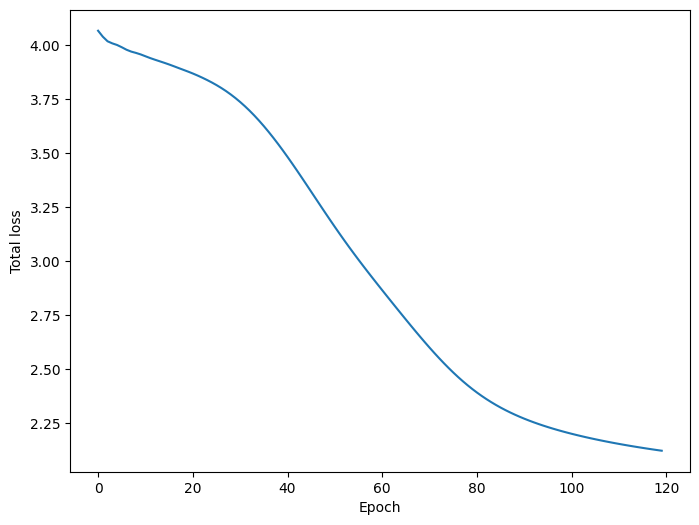

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.plot(losses)
plt.xlabel('Epoch')
plt.ylabel('Total loss')

Next, we'll use the `hyve` visualisation engine library to create an interactive scene that displays the community affiliation of each node. `hyve` works by composing visualisation protocols from simple functional primitives under the `plotdef` operation. The primitives we use here "scatter" data defined parcel-wise (i.e., the community assignments) into the vertices of the fsLR surface (pulled from the TemplateFlow archive) according to the parcel-to-vertex map defined by the 400-region Schaefer parcellation. The data are then resampled onto the faces of the fsLR surface to create a more pleasing visualisation. Finally, the result is plotted interactively, inline in this notebook. (`hyve` implements this kind of interactive plot using the `pyvista` and `trame` libraries.)

In [8]:
import pyvista as pv
from hyve import (
    plotdef,
    surf_from_archive,
    surf_scalars_from_cifti,
    scatter_into_parcels,
    vertex_to_face,
    plot_to_display,
    plot_to_image,
    save_figure,
    Cell,
    GroupSpec,
)
from hyve_examples import get_schaefer400_cifti
pv.set_jupyter_backend('client') # This line is only required in a notebook!

plot_f = plotdef(
    surf_from_archive(),
    surf_scalars_from_cifti('parcellation', plot=False),
    scatter_into_parcels('data', 'parcellation'),
    vertex_to_face('data', interpolation='mode'),
    plot_to_display(),
)
plot_f(
    parcellation_cifti=get_schaefer400_cifti(),
    data_parcellated=model._affiliation.detach().argmax(-1).numpy(),
    surf_scalars_cmap='tab20c',
    surf_scalars_clim=(0, 10),
    surf_scalars_clim_percentile=False,
    window_size=(600, 500),
    empty_builders=True,
);

Widget(value='<iframe src="http://localhost:52131/index.html?ui=P_0x7fa69ec2faf0_0&reconnect=auto" class="pyvi…

We can also use `hyve` to create a multi-panel SVG figure where each detected community is displayed separately. To do this, we first define the layout that we want to use for a single community in the figure. We first arrange layout `Cell`s using a simple "algebra" of operations, and we then annotate each `Cell` to specify the content we would like to display there. Here, we've instructed the plotter to isolate the left and right hemispheres for lateral and medial views, and to display both hemispheres together for the dorsal view. We also modify the composition of our protocol to return static snapshots instead of an interactive scene, and to then arrange those snapshots according to the layout we've specified. In addition to layout, the figure builder primitive here accepts a `GroupSpec`, which replicates the single-community layout we defined for each of the 10 communities present in the dataset.

As a side note, `hyve` works in two steps: the first step is the *composition* or *definition* of a protocol using the `plotdef` function, and the second is the invocation of the protocol using specific arguments. This design facilitates the integration of visualisation protocols into the training loop so that they can help us with model introspection *during* training: the protocol is defined when the model is initialised, and invoked periodically, for instance every few training steps.

(You will almost certainly want to use the `%%capture` directive when calling a `hyve` plotter that produces multiple plots in a notebook. Otherwise, an interactive display might be created for every scene visualised, and all of these displays will simply show the most recent scene.)

In [9]:
%%capture
pv.set_jupyter_backend('trame') # This line is only required in a notebook!

from IPython.display import SVG
from pathlib import Path

OUTPUT_DIR = '/tmp'

layout = Cell() / Cell() << (1 / 2)
layout = layout | Cell() | layout << (1 / 3)
layout = layout | Cell() << (15 / 16)
layout = layout.annotate({
    0: dict(hemisphere='left', view='lateral'),
    1: dict(hemisphere='left', view='medial'),
    2: dict(view='dorsal'),
    3: dict(hemisphere='right', view='lateral'),
    4: dict(hemisphere='right', view='medial'),
    5: dict(elements=['scalar_bar']),
})

plot_f = plotdef(
    surf_from_archive(),
    surf_scalars_from_cifti('parcellation', plot=False),
    scatter_into_parcels('community', 'parcellation'),
    plot_to_image(),
    save_figure(
        layout_kernel=layout,
        group_spec = [
            GroupSpec(
                variable='surfscalars',
                # This might not behave as you would like if you set
                # the number of communities to be odd.
                n_rows=COMMUNITY_DIM // 2,
                n_cols=2,
            ),
        ],
        sort_by=['surfscalars'],
        padding=0,
        canvas_size=(1000, 1200),
        fname_spec='scalars-community',
        scalar_bar_action='collect',
    ),
)
plot_f(
    parcellation_cifti=get_schaefer400_cifti(),
    community_parcellated=model.affiliation.detach().numpy(),
    surf_scalars_cmap='Purples',
    surf_scalars_clim=(0, 1),
    surf_scalars_clim_percentile=False,
    hemisphere=['left', 'right', None],
    views={
        'left': ('medial', 'lateral'),
        'right': ('medial', 'lateral'),
        'both': ('dorsal',),
    },
    window_size=(600, 500),
    output_dir=OUTPUT_DIR,
    fname_spec='scalars-community',
)

And let's show the SVG figure inline. Several of the "dynamic" communities detected by the differentiable program should be recognisable for their similarity to canonical functional brain networks.

In [10]:
display(SVG(
    filename=Path(OUTPUT_DIR) / 'scalars-community_scene.svg'
))

Finally, let's visualise the coaffiliation matrices for each community, and example time series (from the first subject) of the "cohesion" dynamics for each community. (Note that the cohesion time series are fairly temporally smooth, following our regularisation, but they are not switching between "on" and "off" as we might have liked. Depending on how important this is to us, we could either further refine the hyperparameters or train for longer.) (Note also that the time series qualitatively look fairly correlated---perhaps with some lag---suggesting that, when one community is internally cohesive, others tend to be as well.)

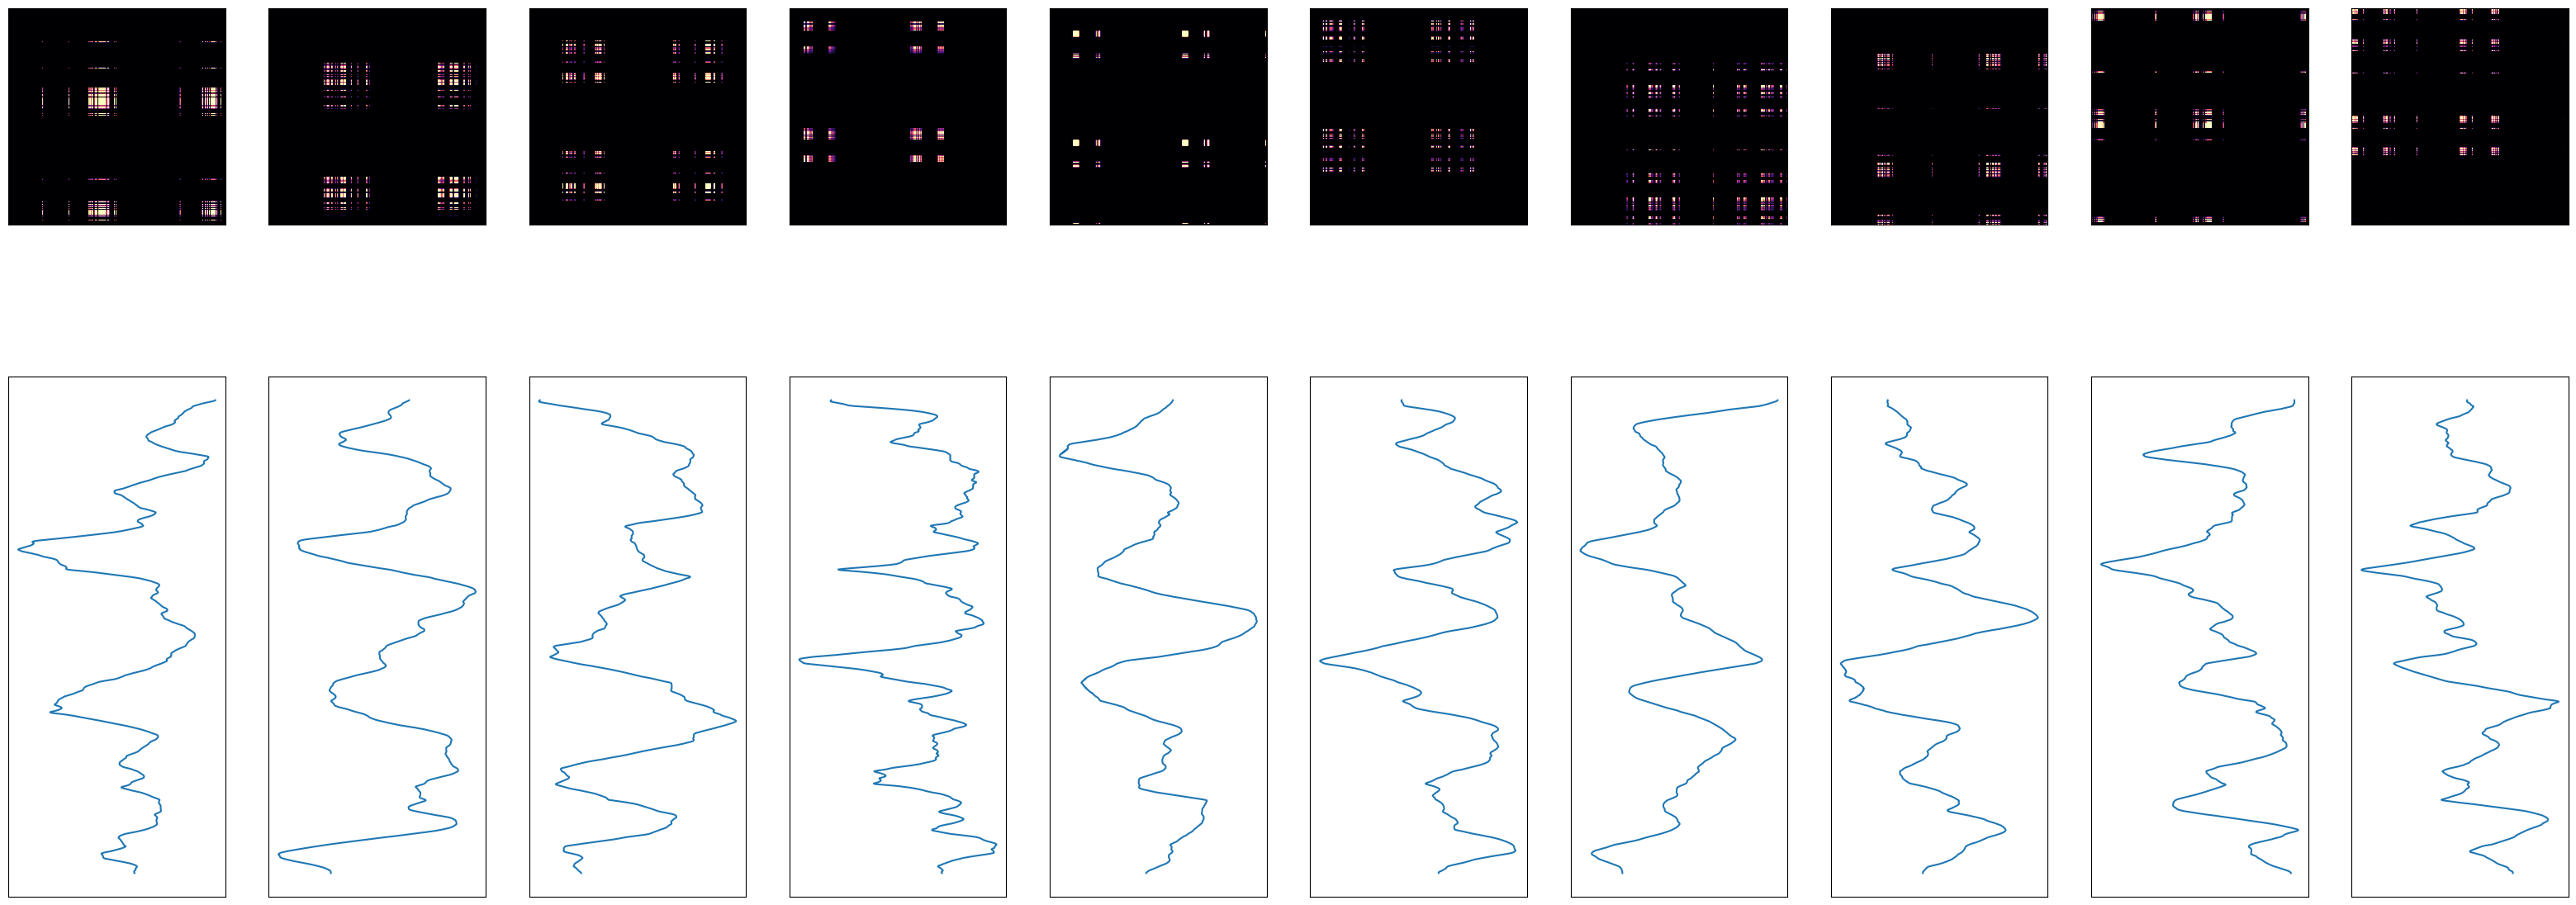

In [11]:
learned = expand_outer(model.affiliation.T.unsqueeze(-1)).detach()
wtlearned = model.dynamics.transpose(0, 1)
fig, axes = plt.subplots(
    2, COMMUNITY_DIM,
    figsize=(4 * COMMUNITY_DIM, 15),
    gridspec_kw={'height_ratios': [4, 6]}
)
for i, ax in enumerate(axes.T):
    ax[0].imshow(learned[i],
                 cmap='magma', vmin=0, vmax=0.6)
    ax[0].set_xticks([])
    ax[0].set_yticks([])
    ax[1].plot(
        wtlearned.detach()[i][0].unsqueeze(0).t(),
        range(TIME_DIM),
    )
    ax[1].set_xticks([])
    ax[1].set_yticks([])

In [12]:
%debug

2024-08-11 16:47:59,252 [   ERROR] No traceback has been produced, nothing to debug.
